In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [10]:
X_train = pd.read_parquet(
    "../data/processed/X_train.parquet"
)

X_val = pd.read_parquet(
    "../data/processed/X_val.parquet"
)

X_test = pd.read_parquet(
    "../data/processed/X_test.parquet"
)

y_train = pd.read_parquet(
    "../data/processed/y_train.parquet"
).squeeze()

y_val = pd.read_parquet(
    "../data/processed/y_val.parquet"
).squeeze()

y_test = pd.read_parquet(
    "../data/processed/y_test.parquet"
).squeeze()

In [11]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

Train: (413378, 663)
Validation: (88581, 663)
Test: (88581, 663)
y_train: (413378,)
y_val: (88581,)
y_test: (88581,)


In [12]:
print("Train fraud rate:", y_train.mean())
print("Validation fraud rate:", y_val.mean())
print("Test fraud rate:", y_test.mean())

print("\nFraud counts:")

print("Train:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

print("\nTest:")
print(y_test.value_counts())

Train fraud rate: 0.03516878014795175
Validation fraud rate: 0.03434145019812375
Test fraud rate: 0.03480430340592226

Fraud counts:
Train:
isFraud
0    398840
1     14538
Name: count, dtype: int64

Validation:
isFraud
0    85539
1     3042
Name: count, dtype: int64

Test:
isFraud
0    85498
1     3083
Name: count, dtype: int64


In [13]:
print("Train missing:", X_train.isnull().sum().sum())
print("Validation missing:", X_val.isnull().sum().sum())
print("Test missing:", X_test.isnull().sum().sum())

Train missing: 0
Validation missing: 0
Test missing: 0


In [14]:
print(
    "Train/Validation columns same:",
    X_train.columns.equals(X_val.columns)
)

print(
    "Train/Test columns same:",
    X_train.columns.equals(X_test.columns)
)

Train/Validation columns same: True
Train/Test columns same: True


In [15]:
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

In [16]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Legitimate:", negative)
print("Fraud:", positive)
print("Scale positive weight:", scale_pos_weight)

Legitimate: 398840
Fraud: 14538
Scale positive weight: 27.434310083918007


In [17]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",
    eval_metric="aucpr",

    random_state=42,
    n_jobs=-1
)

In [18]:
xgb.fit(
    X_train,
    y_train
)
print("XGBoost training completed.")

XGBoost training completed.


In [21]:
xgb_val_prob = xgb.predict_proba(
    X_val
)[:, 1]

print(xgb_val_prob[:10])

[0.09657248 0.9561514  0.5322452  0.05211541 0.02749285 0.12924027
 0.45220572 0.52475035 0.29877183 0.24778247]


In [22]:
xgb_val_pred = (
    xgb_val_prob >= 0.5
).astype(int)

In [23]:
def evaluate_model(
    name,
    y_true,
    y_pred,
    y_prob
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    pr_auc = average_precision_score(
        y_true,
        y_prob
    )

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1       : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")

    print("\nConfusion Matrix:")

    print(
        confusion_matrix(
            y_true,
            y_pred
        )
    )

In [24]:
evaluate_model(
    "XGBoost - Validation - Threshold 0.5",
    y_val,
    xgb_val_pred,
    xgb_val_prob
)

XGBoost - Validation - Threshold 0.5
Accuracy : 0.9385
Precision: 0.3163
Recall   : 0.6798
F1       : 0.4317
ROC-AUC  : 0.9178
PR-AUC   : 0.5556

Confusion Matrix:
[[81068  4471]
 [  974  2068]]


In [25]:
print(
    classification_report(
        y_val,
        xgb_val_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.99      0.95      0.97     85539
           1       0.32      0.68      0.43      3042

    accuracy                           0.94     88581
   macro avg       0.65      0.81      0.70     88581
weighted avg       0.97      0.94      0.95     88581



In [26]:
threshold_results = []

for threshold in np.arange(
    0.05,
    0.96,
    0.05
):

    val_pred = (
        xgb_val_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        val_pred,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,threshold,precision,recall,f1
0,0.05,0.045948,0.990138,0.087821
1,0.10,0.065302,0.963840,0.122317
2,0.15,0.088906,0.929652,0.162291
3,0.20,0.114960,0.893491,0.203710
4,0.25,0.142787,0.855687,0.244735
5,0.30,0.171081,0.809007,0.282435
6,0.35,0.202494,0.774162,0.321020
7,0.40,0.237805,0.743590,0.360363
8,0.45,0.273258,0.707758,0.394286
9,0.50,0.316256,0.679816,0.431688


In [27]:
best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

best_threshold = best_row["threshold"]

print("Best threshold:", best_threshold)
print(
    "Validation Precision:",
    best_row["precision"]
)

print(
    "Validation Recall:",
    best_row["recall"]
)

print(
    "Validation F1:",
    best_row["f1"]
)

Best threshold: 0.7000000000000001
Validation Precision: 0.5300653594771242
Validation Recall: 0.5332018408941486
Validation F1: 0.5316289741068502


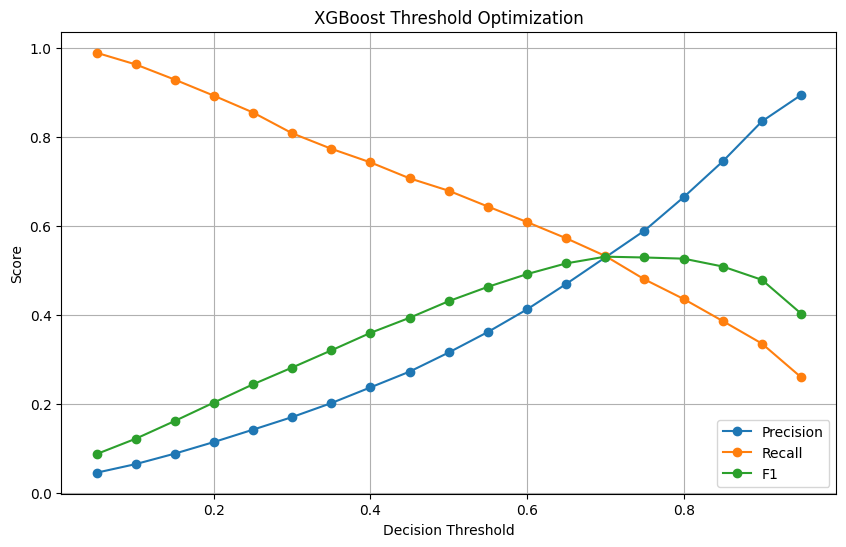

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")

plt.title(
    "XGBoost Threshold Optimization"
)

plt.legend()
plt.grid(True)

plt.show()

In [29]:
xgb_test_prob = xgb.predict_proba(
    X_test
)[:, 1]

In [30]:
xgb_test_pred = (
    xgb_test_prob >= best_threshold
).astype(int)

In [31]:
xgb_test_pred = (
    xgb_test_prob >= best_threshold
).astype(int)

In [32]:
evaluate_model(
    "XGBoost - FINAL TEST",
    y_test,
    xgb_test_pred,
    xgb_test_prob
)

XGBoost - FINAL TEST
Accuracy : 0.9621
Precision: 0.4580
Recall   : 0.4904
F1       : 0.4737
ROC-AUC  : 0.9030
PR-AUC   : 0.5114

Confusion Matrix:
[[83709  1789]
 [ 1571  1512]]


In [33]:
evaluate_model(
    "XGBoost - FINAL TEST",
    y_test,
    xgb_test_pred,
    xgb_test_prob
)

XGBoost - FINAL TEST
Accuracy : 0.9621
Precision: 0.4580
Recall   : 0.4904
F1       : 0.4737
ROC-AUC  : 0.9030
PR-AUC   : 0.5114

Confusion Matrix:
[[83709  1789]
 [ 1571  1512]]


In [34]:
print(
    classification_report(
        y_test,
        xgb_test_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     85498
           1       0.46      0.49      0.47      3083

    accuracy                           0.96     88581
   macro avg       0.72      0.73      0.73     88581
weighted avg       0.96      0.96      0.96     88581



In [35]:
print(
    classification_report(
        y_test,
        xgb_test_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     85498
           1       0.46      0.49      0.47      3083

    accuracy                           0.96     88581
   macro avg       0.72      0.73      0.73     88581
weighted avg       0.96      0.96      0.96     88581



In [36]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
294,V258,0.100678
106,V70,0.063388
293,V257,0.040962
254,V218,0.037914
330,V294,0.033212
127,V91,0.020608
237,V201,0.013718
16,C8,0.012950
331,V295,0.011756
12,C4,0.011302


In [37]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
294,V258,0.100678
106,V70,0.063388
293,V257,0.040962
254,V218,0.037914
330,V294,0.033212
127,V91,0.020608
237,V201,0.013718
16,C8,0.012950
331,V295,0.011756
12,C4,0.011302


In [38]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
294,V258,0.100678
106,V70,0.063388
293,V257,0.040962
254,V218,0.037914
330,V294,0.033212
127,V91,0.020608
237,V201,0.013718
16,C8,0.012950
331,V295,0.011756
12,C4,0.011302
